# Semantic 3D SLAM Dashboard
Loads pre-collected 3D trajectory data and a saved SLAM run, then visualises:
1. True 2D map with agent path
2. RGB frames from the agent's camera
3. Spatial recall heatmaps — the cognitive map learned by SLAM
4. Text-query map (requires CLIP / `pip install torch transformers`)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys, json, glob

# Make sure the project root is on the path regardless of where Jupyter is launched from
PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(".")))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

DATA_DIR = "../data/3d"   # relative to experiments/
print(f"Data dir: {os.path.abspath(DATA_DIR)}")

Data dir: C:\Users\30068379\OneDrive - Western Sydney University\Code\Semantic-Spiking-Neural-SLAM-2023\data\3d


## 1. Load Trajectory and Landmark Data

Path steps:    50
RGB frames:    1  shape (120, 160, 3)
Landmarks:     ['red_box', 'blue_box', 'green_ball', 'yellow_ball']


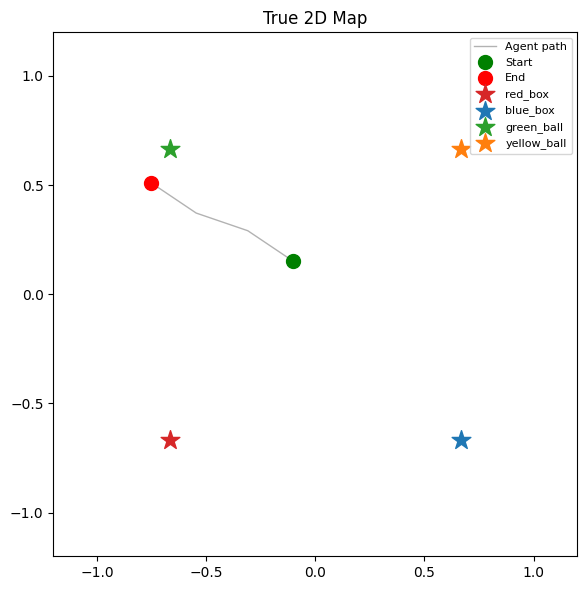

In [2]:
path               = np.load(os.path.join(DATA_DIR, "path.npy"))
rgb_frames         = np.load(os.path.join(DATA_DIR, "rgb_frames_subset.npy"))
landmark_positions = np.load(os.path.join(DATA_DIR, "landmark_positions.npy"))

# Load labels from metadata
meta_path = os.path.join(DATA_DIR, "metadata.json")
with open(meta_path) as f:
    meta = json.load(f)
landmark_labels = meta.get("landmark_labels", [f"obj_{i}" for i in range(len(landmark_positions))])

print(f"Path steps:    {len(path)}")
print(f"RGB frames:    {len(rgb_frames)}  shape {rgb_frames.shape[1:]}")
print(f"Landmarks:     {landmark_labels}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(path[:, 0], path[:, 1], color='gray', alpha=0.6, lw=1, label='Agent path')
ax.plot(path[0, 0], path[0, 1], 'go', ms=10, label='Start')
ax.plot(path[-1, 0], path[-1, 1], 'ro', ms=10, label='End')
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange']
for i, (pos, lbl) in enumerate(zip(landmark_positions, landmark_labels)):
    ax.scatter(*pos, s=200, marker='*', color=colors[i % len(colors)], zorder=5, label=lbl)
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.set_title("True 2D Map")
plt.tight_layout(); plt.show()

## 2. Agent's Camera View Over Time

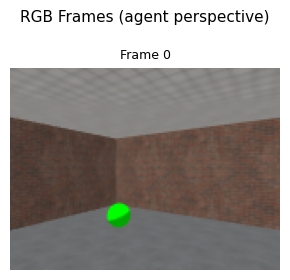

In [3]:
n_show = min(6, len(rgb_frames))
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    idx = i * (len(rgb_frames) // n_show)
    ax.imshow(rgb_frames[idx])
    ax.axis('off')
    ax.set_title(f"Frame {idx}", fontsize=9)
plt.suptitle("RGB Frames (agent perspective)", fontsize=11)
plt.tight_layout(); plt.show()

## 3. Load SLAM Results
Loads the `.npz` saved by `run_slam_features.py` or `run_slam_3d.py`.

In [4]:
npz_files = sorted(glob.glob(os.path.join(DATA_DIR, "slam_features_*.npz")))
if not npz_files:
    raise FileNotFoundError(
        f"No slam_features_*.npz found in {DATA_DIR}.\n"
        "Run: python experiments/run_slam_features.py --feature-data data/3d/feature_vectors.npy "
        "--pos-data data/3d/path.npy --vel-data data/3d/velocities.npy "
        "--vec-data data/3d/vec_to_landmarks.npy --save-dir data/3d"
    )

def _get_T(p):
    """Extract T value from filename, e.g. slam_features_..._T_30_seed_0.npz -> 30."""
    import re
    m = re.search(r'_T_(\d+)_', os.path.basename(p))
    return int(m.group(1)) if m else 0

# Pick the run with the longest simulation time (highest T)
npz_path = max(npz_files, key=_get_T)
print(f"Loading: {os.path.basename(npz_path)}  (T={_get_T(npz_path)}s)")

res = np.load(npz_path, allow_pickle=True)
print("Keys:", list(res.keys()))

obj_locs          = res["obj_locs"]           # (n_objects, 2) true positions
landmark_ssps     = res["landmark_ssps_est"]  # (n_objects, ssp_dim)
landmark_loc_est  = res["landmark_loc_est"]   # (n_objects, 2)
slam_path         = res["slam_path"]           # (T, 2) estimated path
true_path         = res["path"]               # (T, 2) ground truth

n_objects, ssp_dim = landmark_ssps.shape
slam_error = np.linalg.norm(slam_path - true_path[:len(slam_path)], axis=1)

print(f"\n  Objects:       {n_objects}")
print(f"  SSP dim:       {ssp_dim}")
print(f"  SLAM steps:    {len(slam_path)}")
print(f"  Mean error:    {slam_error.mean():.4f} (normalised coords)")
print(f"  True positions:    {obj_locs.round(3)}")
print(f"  Decoded positions: {landmark_loc_est.round(3)}")

Loading: slam_features_sspdim_97_featdim_128_pinneurons_300_T_30_seed_0.npz  (T=30s)
Keys: ['timesteps', 'ts', 'path', 'real_ssp', 'obj_locs', 'view_rad', 'slam_sim_out', 'slam_sims', 'slam_path', 'slam_error', 'landmark_ssps_est', 'landmark_loc_est', 'elapsed_time']

  Objects:       4
  SSP dim:       97
  SLAM steps:    30000
  Mean error:    0.1223 (normalised coords)
  True positions:    [[ 0.459  0.126]
 [ 0.018 -0.649]
 [-0.424  0.377]
 [-0.865 -0.397]]
  Decoded positions: [[-0.899  0.374]
 [ 0.03  -0.616]
 [-0.414  0.414]
 [-0.899  0.374]]


## 4. Path Comparison — True vs SLAM Estimate

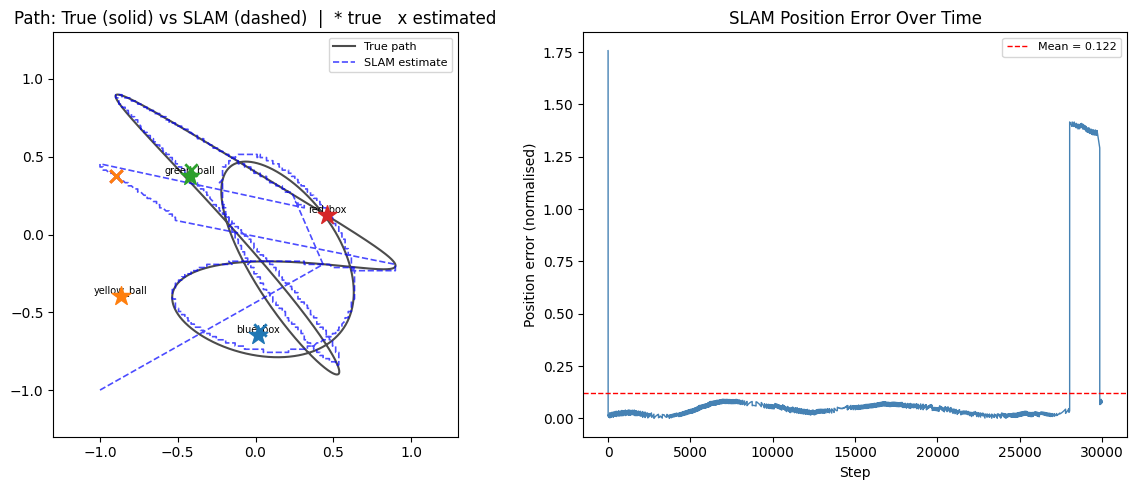

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
n = min(len(slam_path), len(true_path))
ax.plot(true_path[:n, 0], true_path[:n, 1], 'k-', lw=1.5, alpha=0.7, label='True path')
ax.plot(slam_path[:, 0], slam_path[:, 1], 'b--', lw=1.2, alpha=0.7, label='SLAM estimate')
for i, (pos, est, lbl) in enumerate(zip(obj_locs, landmark_loc_est, landmark_labels)):
    c = colors[i % len(colors)]
    ax.scatter(*pos, s=200, marker='*', color=c, zorder=5)
    ax.scatter(*est, s=80, marker='x', color=c, zorder=5, linewidths=2)
    ax.annotate(lbl, pos, fontsize=7, ha='center', va='bottom')
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal'); ax.legend(fontsize=8)
ax.set_title("Path: True (solid) vs SLAM (dashed)  |  * true   x estimated")

axes[1].plot(slam_error, color='steelblue', lw=1)
axes[1].axhline(slam_error.mean(), color='red', ls='--', lw=1, label=f'Mean = {slam_error.mean():.3f}')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Position error (normalised)')
axes[1].set_title('SLAM Position Error Over Time')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## 5. Build SSP Query Grid
Encodes a 60×60 grid of 2D positions as SSPs so we can score the learned memory against every point in space.

In [6]:
from sspslam import HexagonalSSPSpace

ssp_space = HexagonalSSPSpace(
    domain_dim=2, ssp_dim=ssp_dim,
    domain_bounds=np.array([[-1, 1], [-1, 1]])
)

resolution = 60
xs = np.linspace(-1, 1, resolution)
ys = np.linspace(-1, 1, resolution)
xx, yy = np.meshgrid(xs, ys)
grid_pts = np.stack([xx.ravel(), yy.ravel()], axis=1)  # (3600, 2)
grid_ssps = ssp_space.encode(grid_pts)                  # (3600, ssp_dim)

print(f"Grid SSPs: {grid_ssps.shape}")

ModuleNotFoundError: No module named 'sspslam'

## 6. Cognitive Map — Spatial Recall Heatmaps
For each landmark the SLAM network learned, this shows which part of the map the network associates with that object.

In [ ]:
fig, axes = plt.subplots(1, n_objects, figsize=(4 * n_objects, 4))
if n_objects == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    sims = (grid_ssps @ landmark_ssps[i]).reshape(resolution, resolution)

    im = ax.imshow(sims, origin='lower', extent=[-1, 1, -1, 1],
                   cmap='hot', interpolation='bilinear', vmin=0)
    ax.scatter(*obj_locs[i], s=180, marker='*', color='cyan',
               zorder=5, label='True')
    ax.scatter(*landmark_loc_est[i], s=100, marker='x', color='lime',
               zorder=5, linewidths=2.5, label='SLAM est.')
    ax.set_title(landmark_labels[i] if i < len(landmark_labels) else f'Object {i}',
                 fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Cognitive Map — SLAM Spatial Memory (hotter = more associated)",
             fontsize=12)
plt.tight_layout(); plt.show()

## 7. Text Query Map — "Where is the red box?"
Requires `pip install torch transformers`. Skipped gracefully if unavailable.

In [ ]:
TEXT_QUERIES = ["a red box", "a blue box", "a green ball", "a yellow ball"]

try:
    from sspslam.perception.clip_encoder import CLIPFeatureExtractor
    from sspslam.perception.image_feature_encoder import ImageFeatureEncoder

    clip = CLIPFeatureExtractor()
    encoder = ImageFeatureEncoder(feat_dim=clip.feat_dim, ssp_dim=ssp_dim, seed=0)

    query_features = clip.encode_text(TEXT_QUERIES)     # (n_queries, feat_dim)
    query_sps = np.vstack([encoder.encode(q[None]).squeeze() for q in query_features])

    n_q = len(TEXT_QUERIES)
    fig, axes = plt.subplots(1, n_q, figsize=(4 * n_q, 4))
    if n_q == 1: axes = [axes]

    for i, (ax, label) in enumerate(zip(axes, TEXT_QUERIES)):
        sims = (grid_ssps @ query_sps[i]).reshape(resolution, resolution)
        im = ax.imshow(sims, origin='lower', extent=[-1, 1, -1, 1],
                       cmap='hot', interpolation='bilinear')
        for j, pos in enumerate(obj_locs):
            ax.scatter(*pos, s=80, marker='*', color='cyan', zorder=5)
            ax.annotate(landmark_labels[j] if j < len(landmark_labels) else f'obj{j}',
                        pos, fontsize=7, color='white', ha='center', va='bottom')
        ax.set_title(f'"{label}"', fontsize=9)
        ax.set_xlabel('x')
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.suptitle("CLIP Text → SSP Spatial Query", fontsize=12)
    plt.tight_layout(); plt.show()

except Exception as e:
    print(f"CLIP text query skipped: {e}")
    print("Install with: pip install torch transformers")